# Olist — Descriptive Analysis of Every Cleaned Dataset
**Purpose:** See, for yourself, what each of the 18 clean tables contains — column types, nulls, distributions, and a DAMA-5 quality score — plus a verification tab that re-runs the full clean-check. Nothing here modifies your data.

**Scope (18 tables):** 11 flat files in `02_Cleaned_data/` + 7 star-schema tables in `02_Cleaned_data/star_schema/`.

> Generated 2026-08-15 · reads CSVs only · `04_Python/descriptive_lib.py` holds the shared logic.

In [47]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if (ROOT / "04_Python").exists():
    sys.path.insert(0, str(ROOT / "04_Python"))

import descriptive_lib as dl

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": .3, "font.size": 9})

print(f"Registry loaded: {len(dl.TABLES)} tables")

Registry loaded: 18 tables


---
## 0. Everything-at-a-glance

One row per table: rows, columns, primary-key uniqueness, null-bearing columns and the DAMA-5 overall verdict.

In [48]:
ov = dl.overview()
display(ov)

ver = dl.verdict()
c = ver["counts"]
print(f"CLEAN-CHECK: {c['PASS']} PASS | {c['WARN']} WARN | {c['INFO']} INFO | {c['FAIL']} FAIL "
      f"-> {'READY OK' if c['FAIL'] == 0 else 'NOT READY'}")
nonpass = [x for x in ver["checks"] if x["status"] in ("FAIL", "WARN")]
print("\nNon-PASS checks:")
for x in nonpass:
    print(f"  [{x['status']}] {x['check']} ({x['table']}): {x['detail']}")

,Table,File,Group,Rows,Cols,PK unique,Null cols,DAMA-5
0,Master (denormalized),olist_master.csv,Flat files,"96,456",40,✅,19,✅
1,Orders clean,orders_clean.csv,Flat files,"96,456",9,✅,2,✅
2,Orders delivered,orders_delivered.csv,Flat files,"96,478",8,✅,3,✅
3,Payments clean,payments_clean.csv,Flat files,"99,440",4,✅,0,✅
4,Items clean (line),items_clean.csv,Flat files,"112,647",7,✅,0,✅
5,Orders items aggregated,orders_items_aggregated.csv,Flat files,"98,663",7,✅,0,✅
6,Products clean,products_clean.csv,Flat files,"32,951",10,✅,7,✅
7,Reviews clean,reviews_clean.csv,Flat files,"98,673",7,✅,2,✅
8,Geolocation clean,geolocation_clean.csv,Flat files,"19,011",5,✅,0,✅
9,Customers (as-is),olist_customers_dataset.csv,Flat files,"99,441",5,✅,0,✅


CLEAN-CHECK: 110 PASS | 1 WARN | 2 INFO | 0 FAIL -> READY OK

Non-PASS checks:
  [WARN] gap:not_defined (payments_clean): 3 orders carry payment_types_used containing 'not_defined' (canvas §5 says drop 3)


---
## 1. Per-table deep dive

For each of the 18 tables you get:
- **Column report** — name, dtype, nulls (count + %), unique values, samples
- **Numeric columns** — describe (min/median/mean/max) + histogram
- **Categorical columns** — top-10 value counts + bar chart
- **Date columns** — valid range
- **DAMA-5 row** — Completeness / Consistency / Accuracy / Timeliness / Uniqueness

In [49]:
def table_md(p):
    return f"### {p['label']} \n`{p['rel']}` — {p['rows']:,} rows × {p['cols']} cols"

def fmt_num(v):
    try:
        f = float(v)
        return str(int(f)) if f.is_integer() else f"{f:,.2f}"
    except (TypeError, ValueError):
        return v

def column_report(p):
    rows = []
    for c in p["columns"]:
        stat = ""
        if c["kind"] == "numeric":
            s = c.get("stats", {})
            stat = (f"min {fmt_num(s.get('min'))} · med {fmt_num(s.get('median'))} · "
                    f"mean {fmt_num(s.get('mean'))} · max {fmt_num(s.get('max'))}")
        elif c["kind"] == "datetime":
            s = c.get("stats", {})
            stat = f"{s.get('min', '')} -> {s.get('max', '')}"
        rows.append({"Column": c["name"], "Dtype": c["dtype"], "Chart": c["chart"],
                     "Nulls": f"{c['null']:,} ({c['null_pct']}%)",
                     "Unique": f"{c['n_unique']:,}", "Summary": stat,
                     "Samples": ", ".join(str(v) for v in c["samples"][:3])})
    return pd.DataFrame(rows)

def dama_df(d):
    return pd.DataFrame(
        [{"Dimension": k, "Verdict": v[0], "Reason": v[1]}
         for k, v in d["scores"].items()])

_PREF_NOMINAL = ["state", "customer_state", "seller_state", "geolocation_state",
                 "payment_types_used", "category_english", "product_category_name",
                 "weekday", "month_name", "customer_city", "seller_city",
                 "geolocation_city", "city"]

def plot_table(p, max_cols=8):
    df = p["df"]
    charted = [c for c in p["columns"] if c.get("chart") not in ("skip", None)]
    if not charted:
        print("(no plottable columns)")
        return

    flags = [c for c in charted if c["chart"] == "donut"]
    ords = [c for c in charted if c["chart"] == "bar" and c.get("ordered")]
    noms = [c for c in charted if c["chart"] == "bar" and not c.get("ordered")]
    noms.sort(key=lambda c: _PREF_NOMINAL.index(c["name"])
              if c["name"] in _PREF_NOMINAL else 99)
    hists = [c for c in charted if c["chart"] == "hist"]
    trds = [c for c in charted if c["chart"] == "trend"]
    scats = [c for c in charted if c["chart"] == "scatter"]

    items = flags[:2] + ords[:3] + noms[:1] + trds[:1]
    n_scatter = 1 if scats else 0
    items += hists[:max(max_cols - len(items) - n_scatter, 0)]
    if scats:
        items.append(scats[0])  # ONE scatter for the whole coordinate pair
    items = items[:max_cols]

    fig, axes = plt.subplots(1, len(items), figsize=(3.4 * len(items), 2.8),
                             squeeze=False)
    for i, c in enumerate(items):
        ax = axes[0][i]
        label = c.get("label", c["name"])
        name, chart = c["name"], c["chart"]

        if chart == "donut":
            s = pd.to_numeric(df[name], errors="coerce").fillna(0)
            yes = int((s == 1).sum()); total = len(s)
            colors = [dl.PALETTE["warn"] if name == "is_late" else dl.PALETTE["ok"],
                      dl.PALETTE["muted"]]
            ax.pie([yes, max(total - yes, 0)], labels=["yes", "no"],
                   autopct=lambda v: f"{v:.0f}%" if v >= 3 else "",
                   startangle=90, counterclock=False, colors=colors,
                   textprops={"fontsize": 8}, wedgeprops=dict(width=0.45))
            ax.set_title(label, fontsize=9)

        elif chart == "bar":
            s = df[name]
            if c.get("ordered"):
                num = pd.to_numeric(s, errors="coerce")
                if num.notna().any():
                    vc = num.value_counts().sort_index()
                else:
                    vc = s.astype(str).value_counts().sort_index()
            else:
                vc = pd.Series(c.get("top", {})).sort_values()
            ax.bar(range(len(vc)), vc.values, color=dl.PALETTE["ok"])
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels([str(k) for k in vc.index], rotation=45,
                               ha="right", fontsize=7)
            ax.set_title(label, fontsize=9); ax.set_ylabel("orders")

        elif chart == "hist":
            s = pd.to_numeric(df[name], errors="coerce").dropna()
            if s.empty:
                continue
            if name in dl.MONEY_COLS:
                labels, counts, stats = dl.money_bands(s)
                if stats is not None:
                    ax.bar(labels, counts, color=dl.PALETTE["info"], alpha=.85)
                    cap = (f"median R$ {fmt_num(stats['median'])} · "
                           f"mean R$ {fmt_num(stats['mean'])}"
                           + ("" if stats["zeros"] else " · no R$ 0 rows"))
                    ax.set_title(f"{label}\n{cap}", fontsize=8)
                    ax.set_xlabel("R$")
                    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
            else:
                bins = min(30, max(int(s.nunique()), 1))
                ax.hist(s, bins=bins, color=dl.PALETTE["info"], alpha=.85)
                ax.set_title(label, fontsize=9); ax.set_xlabel(name)
            ax.set_ylabel("orders")

        elif chart == "trend":
            s = pd.to_datetime(df[name], errors="coerce").dropna()
            m = s.dt.to_period("M").astype(str).value_counts().sort_index()
            ax.plot(m.index, m.values, color=dl.PALETTE["info"],
                    marker="o", ms=3, lw=1.4)
            ax.tick_params(axis="x", labelrotation=45, labelsize=7)
            ax.set_title(label, fontsize=9); ax.set_xlabel("month")
            ax.set_ylabel("orders")

        elif chart == "scatter":
            lat_c = next((x["name"] for x in scats
                          if x["name"] in ("latitude", "geolocation_lat")), None)
            lng_c = next((x["name"] for x in scats
                          if x["name"] not in ("latitude", "geolocation_lat")), None)
            coords = pd.DataFrame({
                "lng": pd.to_numeric(df[lng_c], errors="coerce"),
                "lat": pd.to_numeric(df[lat_c], errors="coerce")}).dropna()
            hb = ax.hexbin(coords["lng"], coords["lat"], gridsize=45,
                           bins="log", mincnt=1, cmap="viridis", alpha=.85)
            fig.colorbar(hb, ax=ax, fraction=.046, pad=.02, label="zip prefixes")
            ax.set_xlim(-74, -34); ax.set_ylim(-34, 6)
            ax.set_aspect(1 / np.cos(np.deg2rad(15)))
            ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
            ax.set_title("Zip-centroid density (coverage)", fontsize=9)

    plt.tight_layout(); plt.show()

def render_table(key):
    t = next(x for x in dl.TABLES if x["key"] == key)
    p = dl.profile_table(t["rel"])
    d = dl.dama5(p)
    display(pd.DataFrame([{"VERDICT": d["overall"]}]))
    print(table_md(p))
    display(column_report(p))
    display(dama_df(d))
    plot_table(p)


### Master (denormalized)

,VERDICT
0,pass


### Master (denormalized) 
`olist_master.csv` — 96,456 rows × 40 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,order_id,str,skip,0 (0.0%),"96,456",,"bfbd0f9bdef84302105ad712db648a6c, 3b697a20d9e4..."
1,customer_id,str,skip,0 (0.0%),"96,456",,"86dc2ffce2dfff336de2f386a786e574, 355077684019..."
2,order_status,str,bar,0 (0.0%),1,,delivered
3,order_purchase_timestamp,datetime64[us],trend,0 (0.0%),"95,934",2016-09-15 12:16:38 -> 2018-08-29 15:00:37,"2016-09-15 12:16:38, 2016-10-03 09:44:50, 2016..."
4,order_approved_at,datetime64[us],trend,14 (0.01%),"88,253",2016-09-15 12:16:38 -> 2018-08-29 15:10:26,"2016-09-15 12:16:38, 2016-10-06 15:50:54, 2016..."
5,order_delivered_carrier_date,datetime64[us],trend,1 (0.0%),"80,093",2016-10-08 10:34:01 -> 2018-09-11 19:48:28,"2016-11-07 17:11:53, 2016-10-23 14:02:13, 2016..."
6,order_delivered_customer_date,datetime64[us],trend,0 (0.0%),"95,644",2016-10-11 13:46:32 -> 2018-10-17 13:22:46,"2016-11-09 07:47:38, 2016-10-26 14:02:13, 2016..."
7,order_estimated_delivery_date,datetime64[us],trend,0 (0.0%),445,2016-10-04 00:00:00 -> 2018-10-25 00:00:00,"2016-10-04 00:00:00, 2016-10-27 00:00:00, 2016..."
8,delivery_days,Int64,hist,0 (0.0%),132,min 0 · med 10 · mean 12.47 · max 175,"55, 23, 24"
9,customer_unique_id,str,skip,0 (0.0%),"93,336",,"830d5b7aaa3b6f1e9ad63703bec97d23, 32ea3bdedab8..."


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id unique (96,456)"


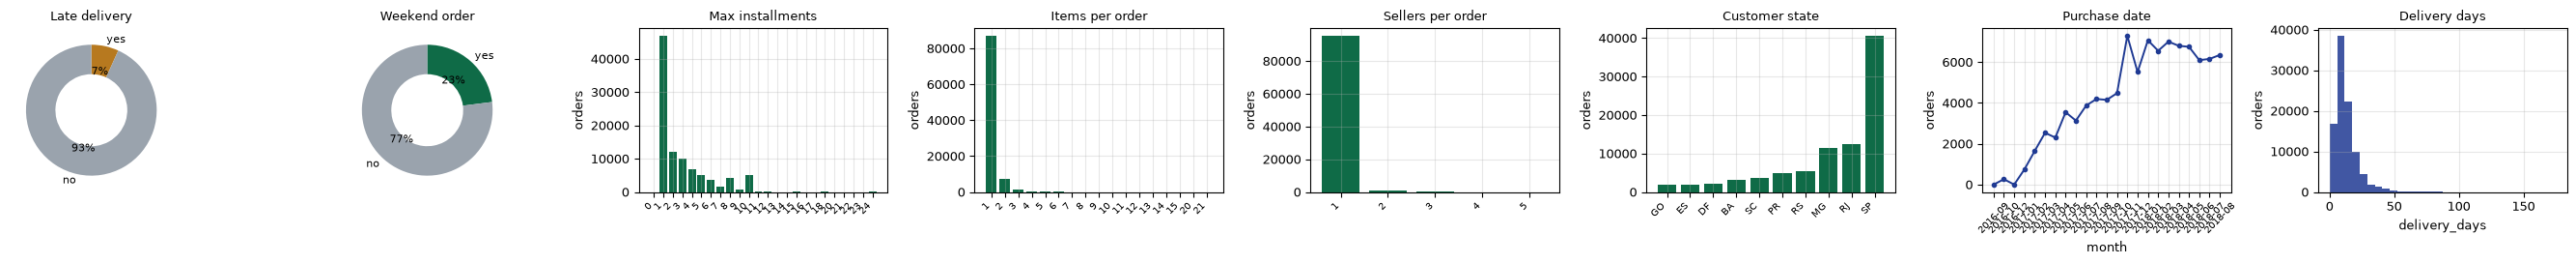

In [50]:
render_table("master")

### Orders clean

,VERDICT
0,pass


### Orders clean 
`orders_clean.csv` — 96,456 rows × 9 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,order_id,str,skip,0 (0.0%),"96,456",,"e481f51cbdc54678b7cc49136f2d6af7, 53cdb2fc8bc7..."
1,customer_id,str,skip,0 (0.0%),"96,456",,"9ef432eb6251297304e76186b10a928d, b0830fb4747a..."
2,order_status,str,bar,0 (0.0%),1,,delivered
3,order_purchase_timestamp,datetime64[us],trend,0 (0.0%),"95,934",2016-09-15 12:16:38 -> 2018-08-29 15:00:37,"2017-10-02 10:56:33, 2018-07-24 20:41:37, 2018..."
4,order_approved_at,datetime64[us],trend,14 (0.01%),"88,253",2016-09-15 12:16:38 -> 2018-08-29 15:10:26,"2017-10-02 11:07:15, 2018-07-26 03:24:27, 2018..."
5,order_delivered_carrier_date,datetime64[us],trend,1 (0.0%),"80,093",2016-10-08 10:34:01 -> 2018-09-11 19:48:28,"2017-10-04 19:55:00, 2018-07-26 14:31:00, 2018..."
6,order_delivered_customer_date,datetime64[us],trend,0 (0.0%),"95,644",2016-10-11 13:46:32 -> 2018-10-17 13:22:46,"2017-10-10 21:25:13, 2018-08-07 15:27:45, 2018..."
7,order_estimated_delivery_date,datetime64[us],trend,0 (0.0%),445,2016-10-04 00:00:00 -> 2018-10-25 00:00:00,"2017-10-18 00:00:00, 2018-08-13 00:00:00, 2018..."
8,delivery_days,Int64,hist,0 (0.0%),132,min 0 · med 10 · mean 12.47 · max 175,"8, 14, 9"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id unique (96,456)"


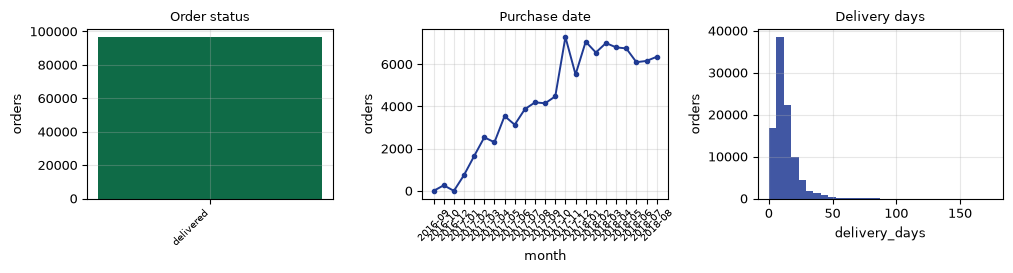

In [51]:
render_table("orders_clean")

### Orders delivered

,VERDICT
0,pass


### Orders delivered 
`orders_delivered.csv` — 96,478 rows × 8 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,order_id,str,skip,0 (0.0%),"96,478",,"e481f51cbdc54678b7cc49136f2d6af7, 53cdb2fc8bc7..."
1,customer_id,str,skip,0 (0.0%),"96,478",,"9ef432eb6251297304e76186b10a928d, b0830fb4747a..."
2,order_status,str,bar,0 (0.0%),1,,delivered
3,order_purchase_timestamp,datetime64[us],trend,0 (0.0%),"95,956",2016-09-15 12:16:38 -> 2018-08-29 15:00:37,"2017-10-02 10:56:33, 2018-07-24 20:41:37, 2018..."
4,order_approved_at,datetime64[us],trend,14 (0.01%),"88,274",2016-09-15 12:16:38 -> 2018-08-29 15:10:26,"2017-10-02 11:07:15, 2018-07-26 03:24:27, 2018..."
5,order_delivered_carrier_date,datetime64[us],trend,2 (0.0%),"80,106",2016-10-08 10:34:01 -> 2018-09-11 19:48:28,"2017-10-04 19:55:00, 2018-07-26 14:31:00, 2018..."
6,order_delivered_customer_date,datetime64[us],trend,8 (0.01%),"95,658",2016-10-11 13:46:32 -> 2018-10-17 13:22:46,"2017-10-10 21:25:13, 2018-08-07 15:27:45, 2018..."
7,order_estimated_delivery_date,datetime64[us],trend,0 (0.0%),445,2016-10-04 00:00:00 -> 2018-10-25 00:00:00,"2017-10-18 00:00:00, 2018-08-13 00:00:00, 2018..."


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id unique (96,478)"


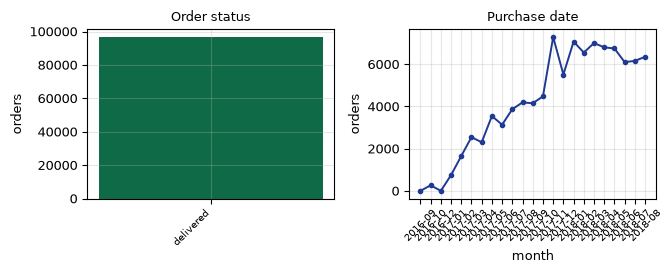

In [52]:
render_table("orders_deliv")

### Payments clean

,VERDICT
0,pass


### Payments clean 
`payments_clean.csv` — 99,440 rows × 4 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,order_id,str,skip,0 (0.0%),"99,440",,"00010242fe8c5a6d1ba2dd792cb16214, 00018f77f2f0..."
1,total_payment_value,float64,hist,0 (0.0%),"27,540","min 0 · med 105.29 · mean 160.99 · max 13,664.08","72.19, 259.83, 216.87"
2,payment_types_used,str,bar,0 (0.0%),7,,"credit_card, boleto, credit_card,voucher"
3,payment_installments_max,int64,bar,0 (0.0%),24,min 0 · med 2 · mean 2.93 · max 24,"2, 3, 5"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id unique (99,440)"


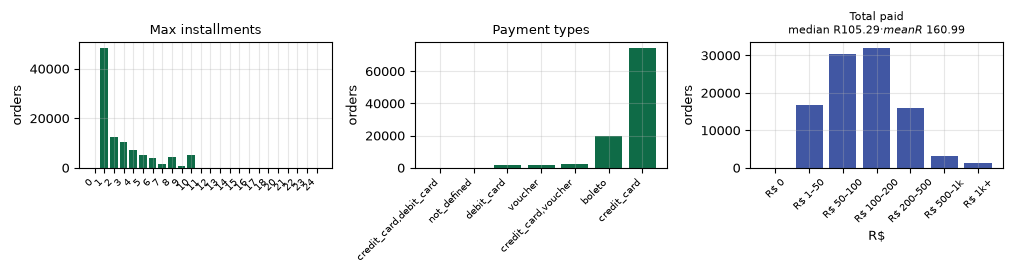

In [53]:
render_table("payments")

### Items clean (line)

,VERDICT
0,pass


### Items clean (line) 
`items_clean.csv` — 112,647 rows × 7 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,order_id,str,skip,0 (0.0%),"98,663",,"00010242fe8c5a6d1ba2dd792cb16214, 00018f77f2f0..."
1,order_item_id,str,bar,0 (0.0%),21,,"1, 2, 3"
2,product_id,str,skip,0 (0.0%),"32,948",,"4244733e06e7ecb4970a6e2683c13e61, e5f2d52b8021..."
3,seller_id,str,skip,0 (0.0%),"3,093",,"48436dade18ac8b2bce089ec2a041202, dd7ddc04e1b6..."
4,shipping_limit_date,datetime64[us],trend,0 (0.0%),"93,315",2016-09-19 00:15:34 -> 2020-04-09 22:35:08,"2017-09-19 09:45:35, 2017-05-03 11:05:13, 2018..."
5,price,float64,hist,0 (0.0%),"5,965",min 0.85 · med 74.99 · mean 120.48 · max 4799,"58.9, 239.9, 199.0"
6,freight_value,float64,hist,0 (0.0%),"6,996",min 0 · med 16.26 · mean 19.99 · max 409.68,"13.29, 19.93, 17.87"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id+order_item_id unique (112,647)"


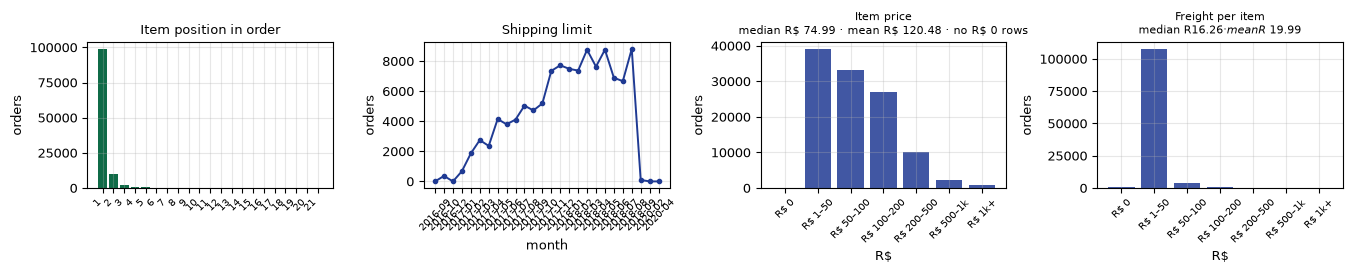

In [54]:
render_table("items")

### Orders items aggregated

,VERDICT
0,pass


### Orders items aggregated 
`orders_items_aggregated.csv` — 98,663 rows × 7 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,order_id,str,skip,0 (0.0%),"98,663",,"00010242fe8c5a6d1ba2dd792cb16214, 00018f77f2f0..."
1,item_count,int64,bar,0 (0.0%),17,min 1 · med 1 · mean 1.14 · max 21,"1, 2, 3"
2,total_items_price,float64,hist,0 (0.0%),"7,555",min 0.85 · med 86.90 · mean 137.56 · max 13440,"58.9, 239.9, 199.0"
3,total_freight,float64,hist,0 (0.0%),"7,557","min 0 · med 17.17 · mean 22.82 · max 1,794.96","13.29, 19.93, 17.87"
4,n_sellers,int64,bar,0 (0.0%),5,min 1 · med 1 · mean 1.01 · max 5,"1, 2, 3"
5,seller_ids,str,skip,0 (0.0%),"4,120",,"48436dade18ac8b2bce089ec2a041202, dd7ddc04e1b6..."
6,product_ids,str,skip,0 (0.0%),"33,898",,"4244733e06e7ecb4970a6e2683c13e61, e5f2d52b8021..."


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id unique (98,663)"


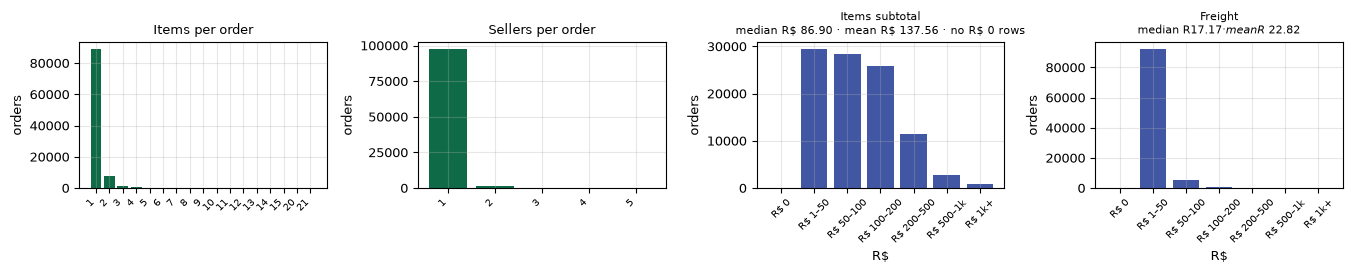

In [55]:
render_table("items_agg")

### Products clean

,VERDICT
0,pass


### Products clean 
`products_clean.csv` — 32,951 rows × 10 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,product_id,str,skip,0 (0.0%),"32,951",,"1e9e8ef04dbcff4541ed26657ea517e5, 3aa071139cb1..."
1,product_category_name,str,bar,0 (0.0%),74,,"perfumaria, artes, esporte_lazer"
2,product_name_lenght,Int64,hist,610 (1.85%),66,min 5 · med 51 · mean 48.48 · max 76,"40, 44, 46"
3,product_description_lenght,Int64,hist,610 (1.85%),"2,960",min 4 · med 595 · mean 771.50 · max 3992,"287, 276, 250"
4,product_photos_qty,Int64,bar,610 (1.85%),19,min 1 · med 1 · mean 2.19 · max 20,"1, 4, 2"
5,product_weight_g,float64,hist,2 (0.01%),"2,204","min 0 · med 700 · mean 2,276.47 · max 40425","225.0, 1000.0, 154.0"
6,product_length_cm,float64,hist,2 (0.01%),99,min 7 · med 25 · mean 30.82 · max 105,"16.0, 30.0, 18.0"
7,product_height_cm,float64,hist,2 (0.01%),102,min 2 · med 13 · mean 16.94 · max 105,"10.0, 18.0, 9.0"
8,product_width_cm,float64,hist,2 (0.01%),95,min 6 · med 20 · mean 23.20 · max 118,"14.0, 20.0, 15.0"
9,category_english,str,bar,0 (0.0%),72,,"perfumery, art, sports_leisure"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"product_id unique (32,951)"


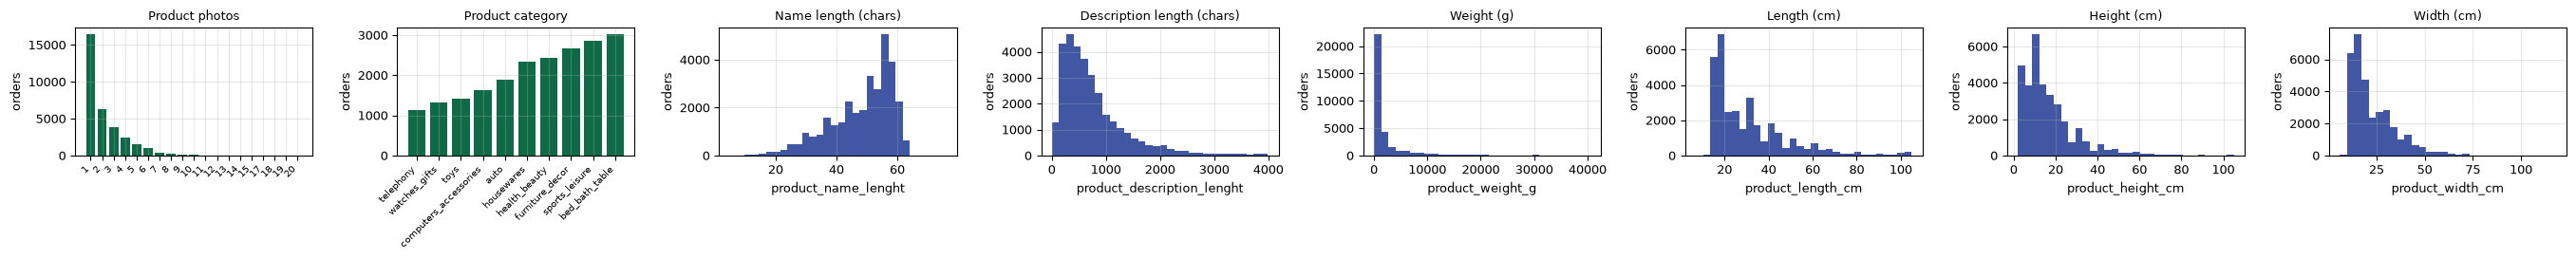

In [56]:
render_table("products")

### Reviews clean

,VERDICT
0,pass


### Reviews clean 
`reviews_clean.csv` — 98,673 rows × 7 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,review_id,str,skip,0 (0.0%),"98,103",,"69ac6a27fde9855ebeaaecac0f78058b, 6916ca4502d6..."
1,order_id,str,skip,0 (0.0%),"98,673",,"809a282bbd5dbcabb6f2f724fca862ec, bfbd0f9bdef8..."
2,review_score,int64,bar,0 (0.0%),5,min 1 · med 5 · mean 4.09 · max 5,"1, 4, 5"
3,review_comment_title,str,skip,"87,123 (88.29%)","4,524",,"super recomendado, otimo, Muito bom."
4,review_comment_message,str,skip,"57,882 (58.66%)","36,073",,MEU PEDIDO NÃO FOI ENTREGUE E NÃO FOI DADA NEN...
5,review_creation_date,datetime64[us],trend,0 (0.0%),636,2016-10-02 00:00:00 -> 2018-08-31 00:00:00,"2016-10-02 00:00:00, 2016-10-06 00:00:00, 2016..."
6,review_answer_timestamp,datetime64[us],trend,0 (0.0%),"97,941",2016-10-07 18:32:28 -> 2018-10-29 12:27:35,"2016-10-26 12:31:00, 2016-10-07 18:32:28, 2016..."


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id unique (98,673)"


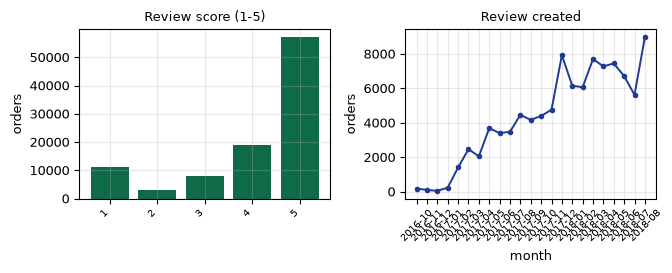

In [57]:
render_table("reviews")

### Geolocation clean

,VERDICT
0,pass


### Geolocation clean 
`geolocation_clean.csv` — 19,011 rows × 5 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,geolocation_zip_code_prefix,str,skip,0 (0.0%),"19,011",,"01037, 01046, 01041"
1,geolocation_city,str,bar,0 (0.0%),"5,952",,"sao paulo, são paulo, osasco"
2,geolocation_state,str,bar,0 (0.0%),27,,"SP, RJ, ES"
3,latitude,float64,scatter,0 (0.0%),"18,983",min -33.69 · med -22.43 · mean -19.08 · max 4.48,"-23.54562128115268, -23.54608112703553, -23.54..."
4,longitude,float64,scatter,0 (0.0%),"18,984",min -72.93 · med -46.63 · mean -46.08 · max -3...,"-46.63929204800168, -46.64482029837157, -46.63..."


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"geolocation_zip_code_prefix unique (19,011)"


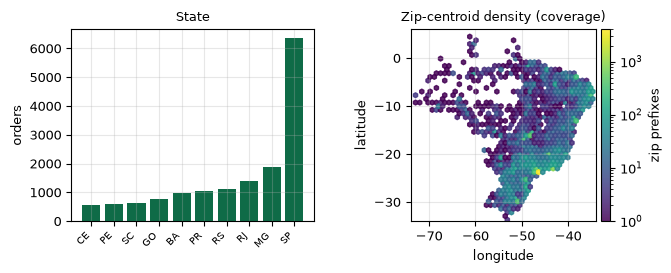

In [58]:
render_table("geolocation")

### Customers (as-is)

,VERDICT
0,pass


### Customers (as-is) 
`olist_customers_dataset.csv` — 99,441 rows × 5 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,customer_id,str,skip,0 (0.0%),"99,441",,"06b8999e2fba1a1fbc88172c00ba8bc7, 18955e83d337..."
1,customer_unique_id,str,skip,0 (0.0%),"96,096",,"861eff4711a542e4b93843c6dd7febb0, 290c77bc529b..."
2,customer_zip_code_prefix,str,skip,0 (0.0%),"14,994",,"14409, 09790, 01151"
3,customer_city,str,bar,0 (0.0%),"4,119",,"franca, sao bernardo do campo, sao paulo"
4,customer_state,str,bar,0 (0.0%),27,,"SP, SC, MG"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"customer_id unique (99,441)"


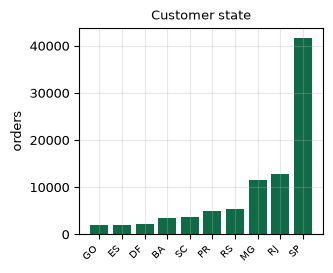

In [59]:
render_table("customers")

### Sellers (as-is)

,VERDICT
0,pass


### Sellers (as-is) 
`olist_sellers_dataset.csv` — 3,095 rows × 4 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,seller_id,str,skip,0 (0.0%),"3,095",,"3442f8959a84dea7ee197c632cb2df15, d1b65fc7debc..."
1,seller_zip_code_prefix,str,skip,0 (0.0%),"2,246",,"13023, 13844, 20031"
2,seller_city,str,bar,0 (0.0%),611,,"campinas, mogi guacu, rio de janeiro"
3,seller_state,str,bar,0 (0.0%),23,,"SP, RJ, PE"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"seller_id unique (3,095)"


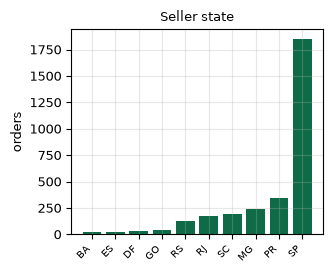

In [60]:
render_table("sellers")

### Star: Fact_Orders

,VERDICT
0,pass


### Star: Fact_Orders 
`star_schema/Fact_Orders.csv` — 96,456 rows × 21 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,order_id,str,skip,0 (0.0%),"96,456",,"bfbd0f9bdef84302105ad712db648a6c, 3b697a20d9e4..."
1,customer_id,str,skip,0 (0.0%),"96,456",,"86dc2ffce2dfff336de2f386a786e574, 355077684019..."
2,order_date,datetime64[us],trend,0 (0.0%),"95,934",2016-09-15 12:16:38 -> 2018-08-29 15:00:37,"2016-09-15 12:16:38, 2016-10-03 09:44:50, 2016..."
3,date_key,int64,skip,0 (0.0%),612,"min 20160915 · med 20180120 · mean 20,176,062....","20160915, 20161003, 20161004"
4,order_revenue,float64,hist,3 (0.0%),"7,432",min 0.85 · med 86.50 · mean 136.83 · max 13440,"134.97, 29.9, 21.9"
5,order_revenue_gross,float64,hist,3 (0.0%),"26,992","min 9.59 · med 105.28 · mean 159.60 · max 13,6...","143.46, 45.46, 39.09"
6,total_freight,float64,hist,3 (0.0%),"7,472","min 0 · med 17.17 · mean 22.78 · max 1,794.96","8.49, 15.56, 17.19"
7,paid_amount,float64,hist,1 (0.0%),"27,029","min 9.59 · med 105.28 · mean 159.84 · max 13,6...","45.46, 39.09, 53.73"
8,payment_installments_max,Int64,bar,1 (0.0%),24,min 0 · med 2 · mean 2.93 · max 24,"1, 6, 4"
9,item_count,Int64,bar,3 (0.0%),17,min 1 · med 1 · mean 1.14 · max 21,"3, 1, 2"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id unique (96,456)"


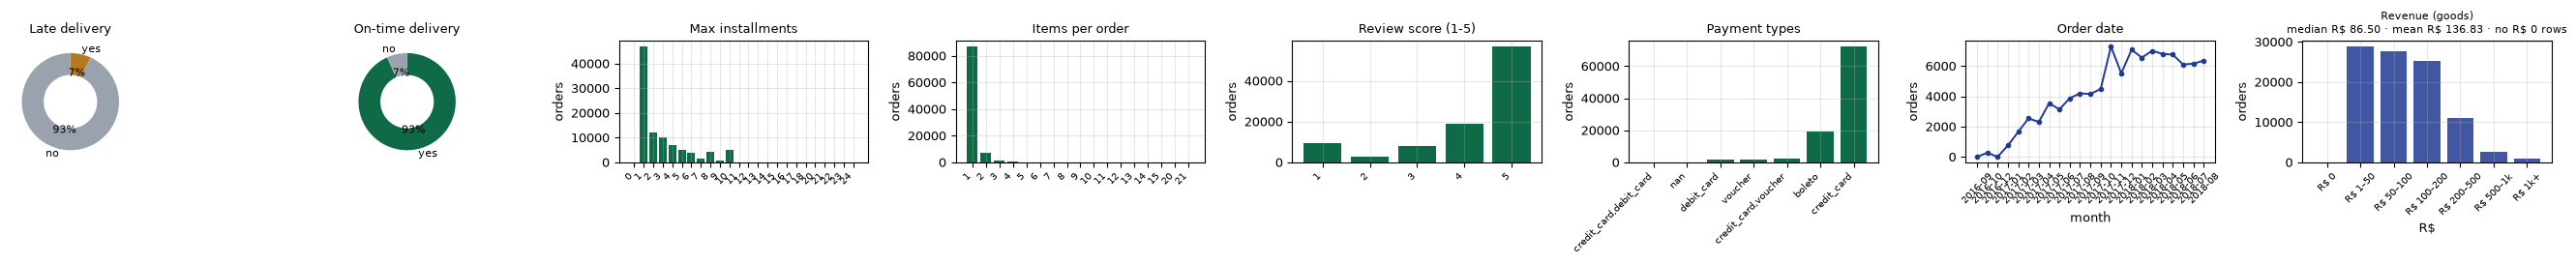

In [61]:
render_table("fact_orders")

### Star: Fact_OrderItems

,VERDICT
0,pass


### Star: Fact_OrderItems 
`star_schema/Fact_OrderItems.csv` — 110,170 rows × 9 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,order_item_id,str,bar,0 (0.0%),21,,"1, 2, 3"
1,order_id,str,skip,0 (0.0%),"96,453",,"00010242fe8c5a6d1ba2dd792cb16214, 00018f77f2f0..."
2,product_id,str,skip,0 (0.0%),"32,207",,"4244733e06e7ecb4970a6e2683c13e61, e5f2d52b8021..."
3,seller_id,str,skip,0 (0.0%),"2,966",,"48436dade18ac8b2bce089ec2a041202, dd7ddc04e1b6..."
4,order_date,datetime64[us],trend,0 (0.0%),"95,931",2016-09-15 12:16:38 -> 2018-08-29 15:00:37,"2017-09-13 08:59:02, 2017-04-26 10:53:06, 2018..."
5,date_key,int64,skip,0 (0.0%),612,"min 20160915 · med 20180121 · mean 20,176,064....","20170913, 20170426, 20180114"
6,line_price,float64,hist,0 (0.0%),"5,855",min 0.85 · med 74.90 · mean 119.79 · max 4799,"58.9, 239.9, 199.0"
7,line_freight,float64,hist,0 (0.0%),"6,920",min 0 · med 16.26 · mean 19.94 · max 409.68,"13.29, 19.93, 17.87"
8,is_late,int64,donut,0 (0.0%),2,min 0 · med 0 · mean 0.07 · max 1,"0, 1"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"order_id+order_item_id unique (110,170)"


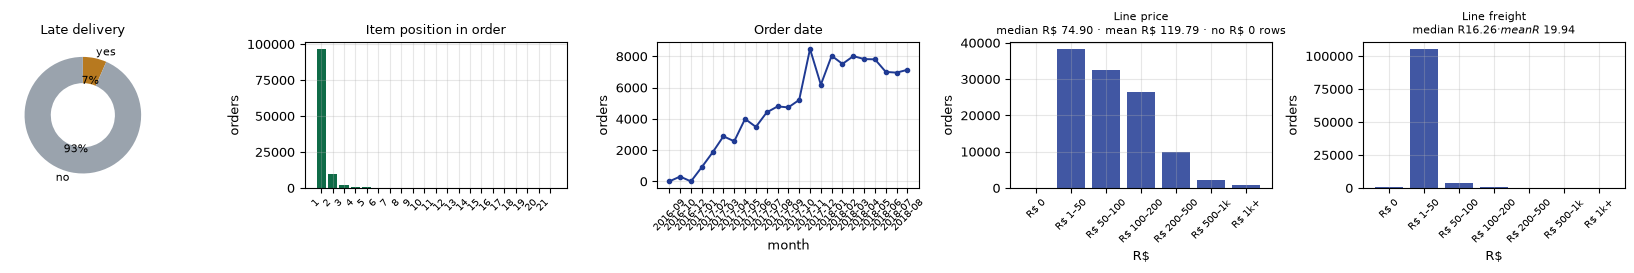

In [62]:
render_table("fact_items")

### Star: Dim_Customer

,VERDICT
0,pass


### Star: Dim_Customer 
`star_schema/Dim_Customer.csv` — 99,441 rows × 5 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,customer_id,str,skip,0 (0.0%),"99,441",,"06b8999e2fba1a1fbc88172c00ba8bc7, 18955e83d337..."
1,customer_unique_id,str,skip,0 (0.0%),"96,096",,"861eff4711a542e4b93843c6dd7febb0, 290c77bc529b..."
2,customer_zip_code_prefix,str,skip,0 (0.0%),"14,994",,"14409, 09790, 01151"
3,customer_city,str,bar,0 (0.0%),"4,119",,"franca, sao bernardo do campo, sao paulo"
4,customer_state,str,bar,0 (0.0%),27,,"SP, SC, MG"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"customer_id unique (99,441)"


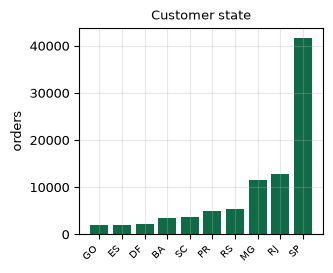

In [63]:
render_table("dim_customer")

### Star: Dim_Product

,VERDICT
0,pass


### Star: Dim_Product 
`star_schema/Dim_Product.csv` — 32,951 rows × 8 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,product_id,str,skip,0 (0.0%),"32,951",,"1e9e8ef04dbcff4541ed26657ea517e5, 3aa071139cb1..."
1,product_category_name,str,bar,0 (0.0%),74,,"perfumaria, artes, esporte_lazer"
2,category_english,str,bar,0 (0.0%),72,,"perfumery, art, sports_leisure"
3,product_weight_g,float64,hist,2 (0.01%),"2,204","min 0 · med 700 · mean 2,276.47 · max 40425","225.0, 1000.0, 154.0"
4,product_length_cm,float64,hist,2 (0.01%),99,min 7 · med 25 · mean 30.82 · max 105,"16.0, 30.0, 18.0"
5,product_height_cm,float64,hist,2 (0.01%),102,min 2 · med 13 · mean 16.94 · max 105,"10.0, 18.0, 9.0"
6,product_width_cm,float64,hist,2 (0.01%),95,min 6 · med 20 · mean 23.20 · max 118,"14.0, 20.0, 15.0"
7,product_photos_qty,Int64,bar,610 (1.85%),19,min 1 · med 1 · mean 2.19 · max 20,"1, 4, 2"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"product_id unique (32,951)"


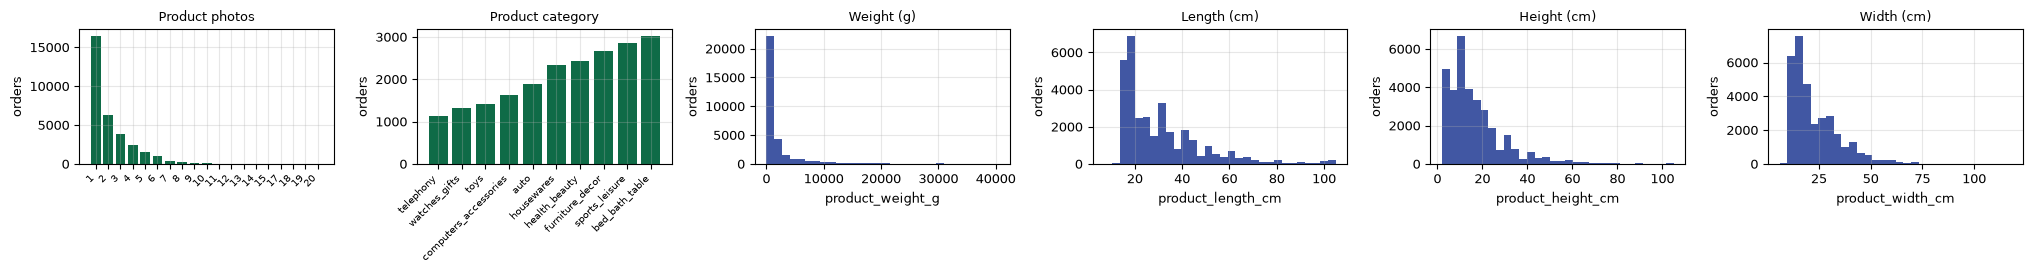

In [64]:
render_table("dim_product")

### Star: Dim_Seller

,VERDICT
0,pass


### Star: Dim_Seller 
`star_schema/Dim_Seller.csv` — 3,095 rows × 4 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,seller_id,str,skip,0 (0.0%),"3,095",,"3442f8959a84dea7ee197c632cb2df15, d1b65fc7debc..."
1,seller_zip_code_prefix,str,skip,0 (0.0%),"2,246",,"13023, 13844, 20031"
2,seller_city,str,bar,0 (0.0%),611,,"campinas, mogi guacu, rio de janeiro"
3,seller_state,str,bar,0 (0.0%),23,,"SP, RJ, PE"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"seller_id unique (3,095)"


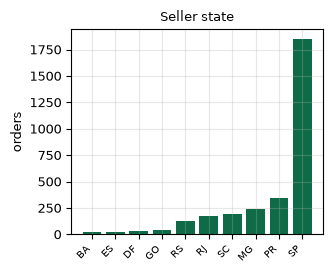

In [65]:
render_table("dim_seller")

### Star: Dim_Geography

,VERDICT
0,pass


### Star: Dim_Geography 
`star_schema/Dim_Geography.csv` — 19,011 rows × 5 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,zip_code_prefix,str,skip,0 (0.0%),"19,011",,"01037, 01046, 01041"
1,latitude,float64,scatter,0 (0.0%),"18,983",min -33.69 · med -22.43 · mean -19.08 · max 4.48,"-23.54562128115268, -23.54608112703553, -23.54..."
2,longitude,float64,scatter,0 (0.0%),"18,984",min -72.93 · med -46.63 · mean -46.08 · max -3...,"-46.63929204800168, -46.64482029837157, -46.63..."
3,city,str,bar,0 (0.0%),"5,952",,"sao paulo, são paulo, osasco"
4,state,str,bar,0 (0.0%),27,,"SP, RJ, ES"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,"zip_code_prefix unique (19,011)"


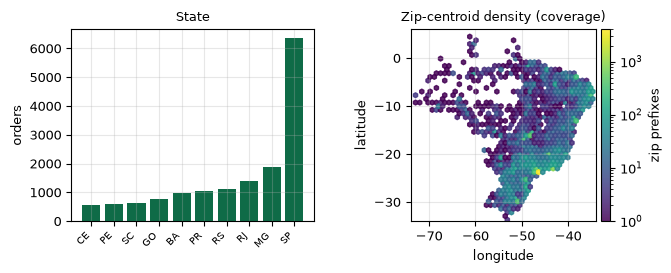

In [66]:
render_table("dim_geo")

### Star: Dim_Date

,VERDICT
0,pass


### Star: Dim_Date 
`star_schema/Dim_Date.csv` — 763 rows × 11 cols


,Column,Dtype,Chart,Nulls,Unique,Summary,Samples
0,date,datetime64[us],trend,0 (0.0%),763,2016-09-15 00:00:00 -> 2018-10-17 00:00:00,"2016-09-15 00:00:00, 2016-09-16 00:00:00, 2016..."
1,date_key,int64,skip,0 (0.0%),763,"min 20160915 · med 20171001 · mean 20,173,066....","20160915, 20160916, 20160917"
2,year,int64,bar,0 (0.0%),3,"min 2016 · med 2017 · mean 2,017.24 · max 2018","2016, 2017, 2018"
3,quarter,int64,bar,0 (0.0%),4,min 1 · med 3 · mean 2.55 · max 4,"3, 4, 1"
4,month,int64,bar,0 (0.0%),12,min 1 · med 7 · mean 6.66 · max 12,"9, 10, 11"
5,month_name,str,bar,0 (0.0%),12,,"September, October, November"
6,day_of_month,int64,bar,0 (0.0%),31,min 1 · med 16 · mean 15.71 · max 31,"15, 16, 17"
7,day_of_week,int64,bar,0 (0.0%),7,min 0 · med 3 · mean 3 · max 6,"3, 4, 5"
8,weekday,str,bar,0 (0.0%),7,,"Thursday, Friday, Saturday"
9,is_weekend,int64,donut,0 (0.0%),2,min 0 · med 0 · mean 0.29 · max 1,"0, 1"


,Dimension,Verdict,Reason
0,Completeness,pass,no unexpected nulls
1,Consistency,pass,domains OK
2,Accuracy,pass,no key/whitespace issues
3,Timeliness,pass,all dates parse & ordered
4,Uniqueness,pass,date_key unique (763)


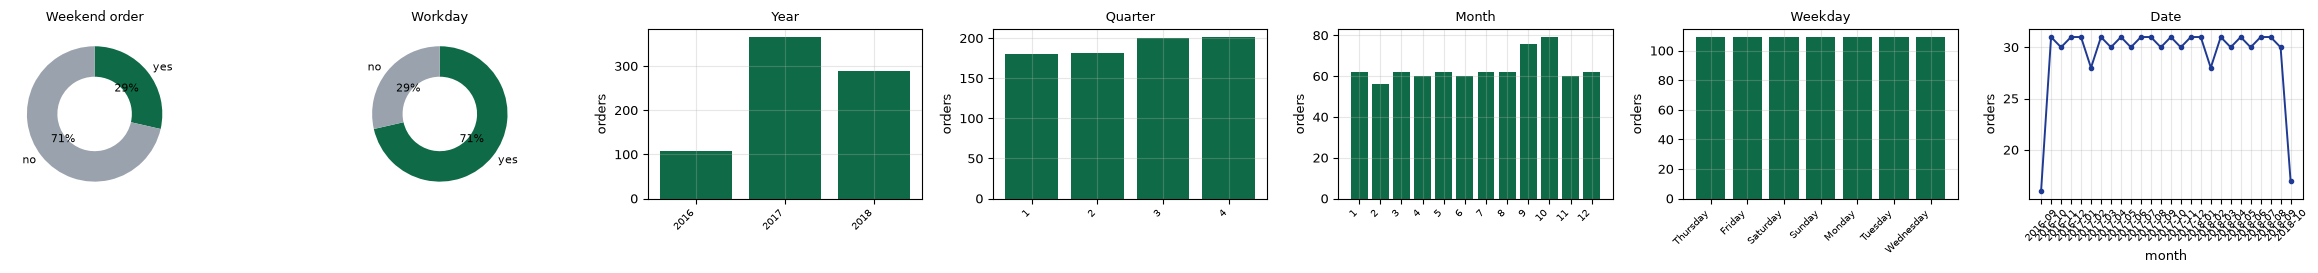

In [67]:
render_table("dim_date")

---
## 2. Verification — "are the cleaning changes good?"

Re-runs `validate_clean_data.py` live against the current CSVs: per-table check badges, reconciliation cards, and the known benign exceptions.

In [68]:
ver = dl.verdict()
c = ver["counts"]
print(f"TOTAL: {c['PASS']} PASS / {c['WARN']} WARN / {c['INFO']} INFO / {c['FAIL']} FAIL")
print("=" * 78)

# Per-table grouping of check results
rows = []
for table, checks in sorted(ver["by_table"].items()):
    st = [x["status"] for x in checks]
    rows.append({"Table/file": table,
                 "checks": len(checks),
                 "PASS": st.count("PASS"),
                 "FAIL": st.count("FAIL"),
                 "WARN": st.count("WARN")})
dfv = pd.DataFrame(rows)
dfv["ok?"] = dfv["FAIL"].apply(lambda n: "YES" if n == 0 else "NO")
display(dfv)

print("\nReconciliation cards (to the cent):")
m = pd.read_csv(dl.CLEAN / "olist_master.csv", dtype={"customer_zip_code_prefix": str})
fo = pd.read_csv(dl.STAR / "Fact_Orders.csv")
fi = pd.read_csv(dl.STAR / "Fact_OrderItems.csv")
print(f"  Fact_Orders.order_revenue   = R$ {fo['order_revenue'].sum():,.2f}")
print(f"  Fact_OrderItems.line_price  = R$ {fi['line_price'].sum():,.2f}")
print(f"  Master   order_revenue      = R$ {m['order_revenue'].astype(float).sum():,.2f}")
print(f"  Fact_Orders.total_freight   = R$ {fo['total_freight'].sum():,.2f}")
print(f"  Fact_OrderItems.line_freight= R$ {fi['line_freight'].sum():,.2f}")
print(f"  Master == Fact_Orders grain = {len(m) == len(fo)} ({len(m):,} rows)")

print("\nKnown benign exceptions (documented, expected):")
print("  - 3 orders with payment_types_used = 'not_defined' (kept, negligible)")
print("  - 645 orders without a review_score (kept null, do not impute)")
print("  - review_comment_title ~88% null (excluded from KPIs by design)")
print("  - geolocation covers ~19k of ~4M BR zips (state-level maps only)")

TOTAL: 110 PASS / 1 WARN / 2 INFO / 0 FAIL


,Table/file,checks,PASS,FAIL,WARN,ok?
0,Dim_Customer,1,1,0,0,YES
1,Dim_Date,1,1,0,0,YES
2,Dim_Product,1,1,0,0,YES
3,Dim_Seller,1,1,0,0,YES
4,Fact_OrderItems,1,1,0,0,YES
5,Fact_Orders,4,4,0,0,YES
6,geolocation_clean.csv,4,4,0,0,YES
7,items_clean.csv,5,5,0,0,YES
8,master,2,2,0,0,YES
9,olist_customers_dataset.csv,4,4,0,0,YES



Reconciliation cards (to the cent):
  Fact_Orders.order_revenue   = R$ 13,197,189.09
  Fact_OrderItems.line_price  = R$ 13,197,189.09
  Master   order_revenue      = R$ 13,197,189.09
  Fact_Orders.total_freight   = R$ 2,197,044.12
  Fact_OrderItems.line_freight= R$ 2,197,044.12
  Master == Fact_Orders grain = True (96,456 rows)

Known benign exceptions (documented, expected):
  - 3 orders with payment_types_used = 'not_defined' (kept, negligible)
  - 645 orders without a review_score (kept null, do not impute)
  - review_comment_title ~88% null (excluded from KPIs by design)
  - geolocation covers ~19k of ~4M BR zips (state-level maps only)


---
## 3. Cross-table sanity

Star-schema referential integrity, master↔star grain match and zip leading-zero preservation.

In [69]:
fo = pd.read_csv(dl.STAR / "Fact_Orders.csv", dtype=str)
fi = pd.read_csv(dl.STAR / "Fact_OrderItems.csv", dtype=str)
dc = pd.read_csv(dl.STAR / "Dim_Customer.csv", dtype=str)
dp = pd.read_csv(dl.STAR / "Dim_Product.csv", dtype=str)
ds = pd.read_csv(dl.STAR / "Dim_Seller.csv", dtype=str)
dd = pd.read_csv(dl.STAR / "Dim_Date.csv", dtype=str)
dg = pd.read_csv(dl.STAR / "Dim_Geography.csv", dtype=str)

print(f"1) Fact_OrderItems.order_id not in Fact_Orders: {len(set(fi['order_id']) - set(fo['order_id']))}")
print(f"2) Fact_OrderItems.product_id unresolved:        {len(set(fi['product_id']) - set(dp['product_id']))}")
print(f"3) Fact_OrderItems.seller_id unresolved:         {len(set(fi['seller_id']) - set(ds['seller_id']))}")
print(f"4) Fact_Orders.customer_id unresolved:           {len(set(fo['customer_id']) - set(dc['customer_id']))}")
print(f"5) Fact date_key unresolved in Dim_Date:         {len((set(fo['date_key']) - set(dd['date_key'])) | (set(fi['date_key']) - set(dd['date_key'])))}")
print(f"6) Master rows == Fact_Orders rows:              {len(m) == len(fo)}")

# Zip leading-zero preservation (CEP is leading-zero significant)
checks = dl.verdict()["checks"]
zip_fails = [x for x in checks if x["check"] == "zip" and x["status"] == "FAIL"]
zip_passes = [x for x in checks if x["check"] == "zip" and x["status"] == "PASS"]
print(f"\n7) Zip leading-zero integrity: {len(zip_passes)} PASS / {len(zip_fails)} FAIL")
for x in zip_passes[:4]:
    print(f"     [PASS] {x['detail']}")

1) Fact_OrderItems.order_id not in Fact_Orders: 0
2) Fact_OrderItems.product_id unresolved:        0
3) Fact_OrderItems.seller_id unresolved:         0
4) Fact_Orders.customer_id unresolved:           0
5) Fact date_key unresolved in Dim_Date:         0
6) Master rows == Fact_Orders rows:              True

7) Zip leading-zero integrity: 7 PASS / 0 FAIL
     [PASS] olist_master.csv.customer_zip_code_prefix: leading-zero zips preserved (raw 23,995 -> clean 23,255)
     [PASS] olist_customers_dataset.csv.customer_zip_code_prefix: leading-zero zips preserved (raw 23,995 -> clean 23,995)
     [PASS] olist_sellers_dataset.csv.seller_zip_code_prefix: leading-zero zips preserved (raw 1,027 -> clean 1,027)
     [PASS] geolocation_clean.csv.geolocation_zip_code_prefix: leading-zero zips preserved (raw 245,733 -> clean 4,354)


---
## Done

Every table profiled (type, nulls, distribution, DAMA-5), the clean-check re-verified live, and cross-table integrity confirmed. The same content is exported as an interactive HTML report:
`06_AI/Outputs/Generated_Reports/descriptive_analysis.html`.